<a href="https://colab.research.google.com/github/zaibshahzadi/DL-Internship/blob/main/DeepLearning_Titanic_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Libraries + Data Load**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Data Cleaning**

In [ ]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print(df.isna().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


**Convert Categorical Columns into Numbers**

In [ ]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


**Features (X) and Label (y)**

In [ ]:
X = df.drop(columns=["Survived"]).values.astype(float)
y = df["Survived"].values.reshape(-1, 1)

print(X.shape, y.shape)

(891, 8) (891, 1)


**Train/Test Split + Standardization**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

X_train_T = X_train.T
X_test_T = X_test.T
y_train_T = y_train.T
y_test_T = y_test.T

**Parameters Initialize**

In [ ]:
np.random.seed(42)

n_x = X_train_T.shape[0]
n_h = 16
n_y = 1

W1 = np.random.randn(n_h, n_x) * 0.01
b1 = np.zeros((n_h, 1))
W2 = np.random.randn(n_y, n_h) * 0.01
b2 = np.zeros((n_y, 1))

**Activation Functions**

In [ ]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

**Forward Propagation**

In [ ]:
def forward_propagation(X, W1, b1, W2, b2):
    Z1 = W1 @ X + b1
    A1 = relu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)
    cache = (Z1, A1, Z2, A2)
    return A2, cache

**Cost Function**

In [ ]:
def compute_cost(A2, Y):
    m = Y.shape[1]
    eps = 1e-8
    cost = -np.sum(Y * np.log(A2 + eps) + (1 - Y) * np.log(1 - A2 + eps)) / m
    return float(np.squeeze(cost))

**Backward Propagation**

In [ ]:
def backward_propagation(X, Y, cache, W2):
    m = X.shape[1]
    Z1, A1, Z2, A2 = cache

    dZ2 = A2 - Y
    dW2 = (dZ2 @ A1.T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    dA1 = W2.T @ dZ2
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (dZ1 @ X.T) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    return dW1, db1, dW2, db2

**Update Parameters + Accuracy Function**

In [ ]:
def update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    return W1, b1, W2, b2

def accuracy(A2, Y):
    predictions = (A2 > 0.5).astype(int)
    return float(np.mean(predictions == Y))

**Training Loop**

In [ ]:
learning_rate = 0.1
epochs = 3000

train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(epochs):
    A2_train, cache = forward_propagation(X_train_T, W1, b1, W2, b2)
    cost = compute_cost(A2_train, y_train_T)
    dW1, db1, dW2, db2 = backward_propagation(X_train_T, y_train_T, cache, W2)
    W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)

    A2_test, _ = forward_propagation(X_test_T, W1, b1, W2, b2)
    test_cost = compute_cost(A2_test, y_test_T)

    train_losses.append(cost)
    test_losses.append(test_cost)
    train_accs.append(accuracy(A2_train, y_train_T))
    test_accs.append(accuracy(A2_test, y_test_T))

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Train Loss: {cost:.4f} | Test Loss: {test_cost:.4f} "
              f"| Train Acc: {train_accs[-1]:.3f} | Test Acc: {test_accs[-1]:.3f}")

print(f"\nFinal Test Accuracy: {test_accs[-1]*100:.2f}%")

Epoch    0 | Train Loss: 0.6932 | Test Loss: 0.6918 | Train Acc: 0.581 | Test Acc: 0.615
Epoch  500 | Train Loss: 0.4171 | Test Loss: 0.4498 | Train Acc: 0.812 | Test Acc: 0.799
Epoch 1000 | Train Loss: 0.3928 | Test Loss: 0.4396 | Train Acc: 0.838 | Test Acc: 0.810
Epoch 1500 | Train Loss: 0.3804 | Test Loss: 0.4416 | Train Acc: 0.844 | Test Acc: 0.799
Epoch 2000 | Train Loss: 0.3747 | Test Loss: 0.4454 | Train Acc: 0.848 | Test Acc: 0.793
Epoch 2500 | Train Loss: 0.3713 | Test Loss: 0.4509 | Train Acc: 0.850 | Test Acc: 0.799

Final Test Accuracy: 77.65%


**Loss & Accuracy Curves**

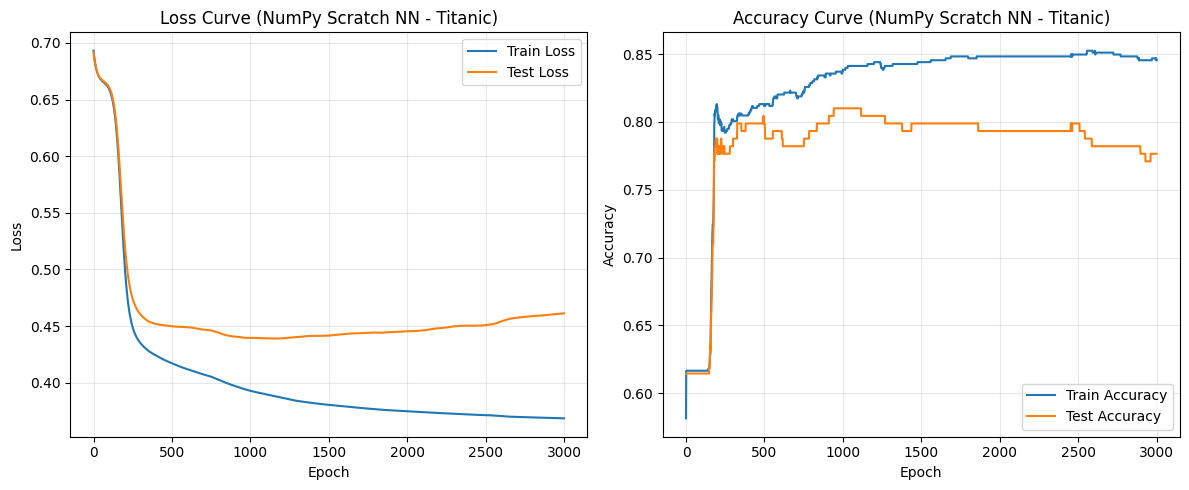

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(test_losses, label="Test Loss")
axes[0].set_title("Loss Curve (NumPy Scratch NN - Titanic)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(train_accs, label="Train Accuracy")
axes[1].plot(test_accs, label="Test Accuracy")
axes[1].set_title("Accuracy Curve (NumPy Scratch NN - Titanic)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Evaluation Metrics**

Confusion Matrix:
[[97 13]
 [27 42]]

Precision: 0.7636
Recall:    0.6087
F1-Score:  0.6774

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.78      0.88      0.83       110
    Survived       0.76      0.61      0.68        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.75       179
weighted avg       0.78      0.78      0.77       179



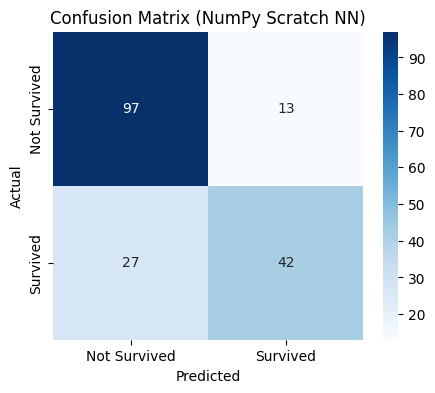

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report
import seaborn as sns

final_preds = (A2_test > 0.5).astype(int).flatten()
final_actual = y_test_T.flatten()

cm = confusion_matrix(final_actual, final_preds)
print("Confusion Matrix:")
print(cm)

precision = precision_score(final_actual, final_preds)
recall = recall_score(final_actual, final_preds)
f1 = f1_score(final_actual, final_preds)
print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(final_actual, final_preds, target_names=["Not Survived", "Survived"]))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Survived", "Survived"],
            yticklabels=["Not Survived", "Survived"])
plt.title("Confusion Matrix (NumPy Scratch NN)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

**Re-implementation using PyTorch , Dropout + L2 Regularization**

**Imports Libraries**

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

**Data Cleaning + Preprocessing**

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

X = df.drop(columns=["Survived"]).values.astype(np.float32)
y = df["Survived"].values.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

**MLP Model**

In [ ]:
class TitanicMLP(nn.Module):
    def __init__(self, in_features=8, hidden1=32, hidden2=16, out_classes=2, dropout_p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden1),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden2, out_classes)
        )

    def forward(self, x):
        return self.net(x)

model = TitanicMLP()
print(model)

TitanicMLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=2, bias=True)
  )
)


**Loss + Optimizer (L2 Regularization)**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

**Training Loop**

In [ ]:
epochs = 200
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    train_preds = outputs.argmax(dim=1)
    train_acc = (train_preds == y_train_t).float().mean().item()

    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_t)
        test_loss = criterion(test_outputs, y_test_t)
        test_preds = test_outputs.argmax(dim=1)
        test_acc = (test_preds == y_test_t).float().mean().item()

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f} "
              f"| Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")

print(f"\nFinal Test Accuracy: {test_accs[-1]*100:.2f}%")

Epoch   0 | Train Loss: 0.7140 | Test Loss: 0.7105 | Train Acc: 0.378 | Test Acc: 0.419
Epoch  20 | Train Loss: 0.6578 | Test Loss: 0.6493 | Train Acc: 0.639 | Test Acc: 0.631
Epoch  40 | Train Loss: 0.6008 | Test Loss: 0.5871 | Train Acc: 0.635 | Test Acc: 0.626
Epoch  60 | Train Loss: 0.5630 | Test Loss: 0.5451 | Train Acc: 0.709 | Test Acc: 0.687
Epoch  80 | Train Loss: 0.5352 | Test Loss: 0.5234 | Train Acc: 0.765 | Test Acc: 0.810
Epoch 100 | Train Loss: 0.5111 | Test Loss: 0.5062 | Train Acc: 0.796 | Test Acc: 0.821
Epoch 120 | Train Loss: 0.4960 | Test Loss: 0.4908 | Train Acc: 0.801 | Test Acc: 0.804
Epoch 140 | Train Loss: 0.4887 | Test Loss: 0.4790 | Train Acc: 0.802 | Test Acc: 0.804
Epoch 160 | Train Loss: 0.4811 | Test Loss: 0.4663 | Train Acc: 0.808 | Test Acc: 0.810
Epoch 180 | Train Loss: 0.4651 | Test Loss: 0.4573 | Train Acc: 0.803 | Test Acc: 0.810

Final Test Accuracy: 81.01%


**Loss & Accuracy Curves**

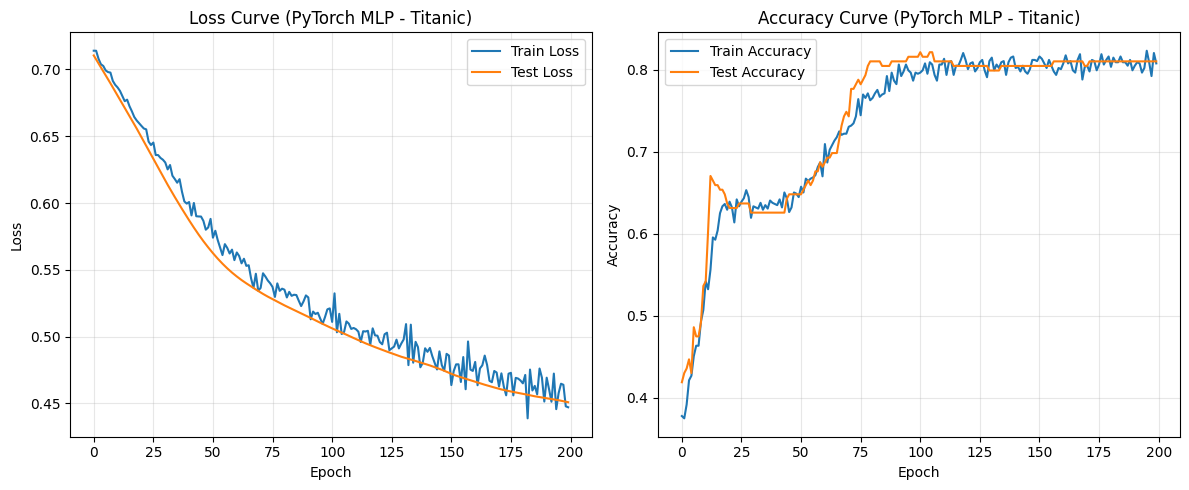

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(test_losses, label="Test Loss")
axes[0].set_title("Loss Curve (PyTorch MLP - Titanic)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(train_accs, label="Train Accuracy")
axes[1].plot(test_accs, label="Test Accuracy")
axes[1].set_title("Accuracy Curve (PyTorch MLP - Titanic)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Evaluation Metrics**

Confusion Matrix:
[[96 14]
 [20 49]]

Precision (macro): 0.8027
Recall (macro):    0.7914
F1-Score (macro):  0.7960

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.83      0.87      0.85       110
    Survived       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



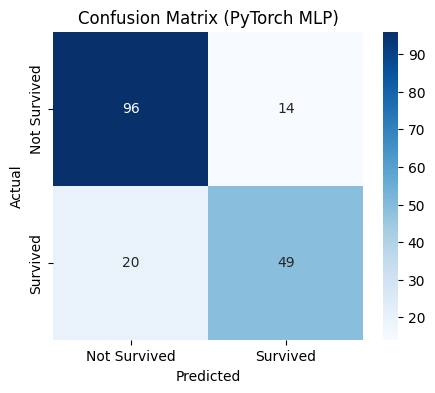

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report
import seaborn as sns

model.eval()
with torch.no_grad():
    final_outputs = model(X_test_t)
    final_preds = final_outputs.argmax(dim=1).numpy()

final_actual = y_test_t.numpy()
class_names = ["Not Survived", "Survived"]

cm = confusion_matrix(final_actual, final_preds)
print("Confusion Matrix:")
print(cm)

precision = precision_score(final_actual, final_preds, average="macro")
recall = recall_score(final_actual, final_preds, average="macro")
f1 = f1_score(final_actual, final_preds, average="macro")
print(f"\nPrecision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"F1-Score (macro):  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(final_actual, final_preds, target_names=class_names))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (PyTorch MLP)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()